# Analyzing Software Engineering as a Lifecycle Process
- Modeling and concept mapping
- Rolling IQR anomaly detection
- Utility experiment


## 1. Load DuckDB and build weekly counts


Dataset: yargs
DuckDB: C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\data\raw\yargs.duckdb
OCEL2: C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\data\raw\yargs.sqlite
Closed event type id: 65


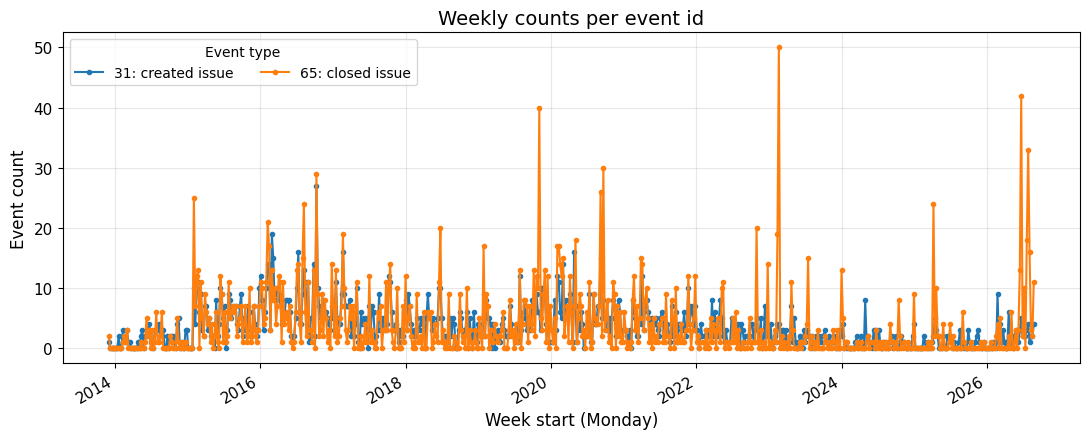

Saved C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\results\tables\yargs\weekly_open_closed_summary.csv


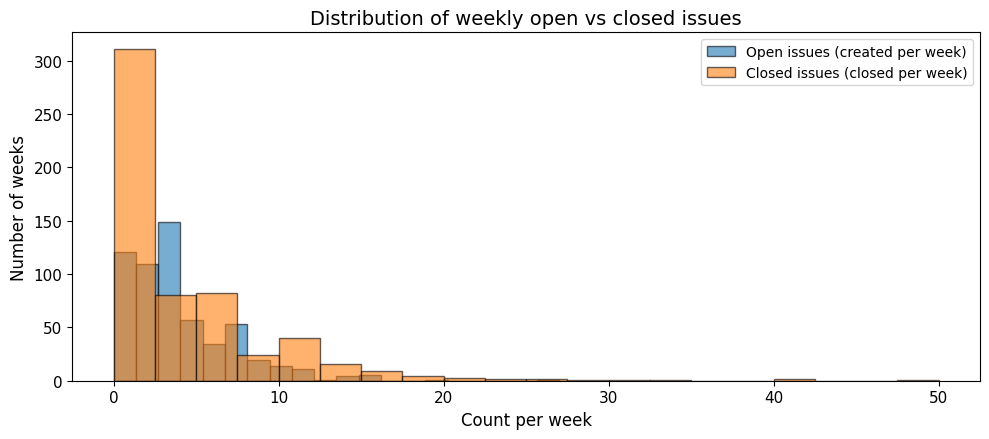

,Open issues (weekly created),Closed issues (weekly closed)
count,579.00,579.00
mean,4.03,4.23
std,3.26,5.79
min,0.00,0.00
25%,2.00,1.00
50%,3.00,2.00
75%,5.00,6.00
max,27.00,50.00


In [1]:
import sys
from pathlib import Path

root = Path.cwd().resolve()
if not (root / "functions").exists():
    root = root.parent
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

from functions.configs import load_dataset_config
from functions.data_loading import (
    build_weekly_issue_counts,
    load_events_per_obj,
    load_objects_attributes,
)
from functions.plotting_anomaly import (
    plot_weekly_event_counts,
    plot_weekly_open_vs_closed_histogram,
    weekly_open_closed_summary_table,
)

# The only dataset-specific line in this notebook.
cfg = load_dataset_config("yargs")

cfg.tables_dir.mkdir(parents=True, exist_ok=True)
cfg.figures_dir.mkdir(parents=True, exist_ok=True)
cfg.figures_no_titles_dir.mkdir(parents=True, exist_ok=True)

print("Dataset:", cfg.dataset_name)
print("DuckDB:", cfg.duckdb_path)
print("OCEL2:", cfg.sqlite_path)
print("Closed event type id:", cfg.closed_event_type_id)

eventsPerobj_df = load_events_per_obj(cfg)
objects_attributes = load_objects_attributes(cfg)
weekly = build_weekly_issue_counts(eventsPerobj_df, cfg)
plot_weekly_event_counts(weekly, cfg)
summary_table = weekly_open_closed_summary_table(weekly, cfg)
plot_weekly_open_vs_closed_histogram(weekly, cfg)
summary_table


## 2. Rolling IQR for detecting the anomalies 


In [2]:
from functions.anomaly import rolling_iqr_detect
from functions.config import IQR_CONFIG

rolling_iqr_anomalies = rolling_iqr_detect(
    weekly[cfg.closed_event_type_id],
    **IQR_CONFIG,
)
rolling_iqr_anomalies.to_csv(cfg.tables_dir / "rolling_iqr_anomalies.csv", index=False)
print(
    f"Detected {int(rolling_iqr_anomalies['is_anomaly'].sum())} "
    f"rolling-IQR anomalies for event_type_id={cfg.closed_event_type_id}."
)
rolling_iqr_anomalies.head()


Detected 50 rolling-IQR anomalies for event_type_id=65.


,week_start,value,rolling_q1,rolling_q3,iqr,lower_bound,upper_bound,is_anomaly,anomaly_direction,anomaly_score
0,2013-12-02,2,NaN,NaN,NaN,NaN,NaN,False,normal,0.0
1,2014-01-20,0,NaN,NaN,NaN,NaN,NaN,False,normal,0.0
2,2014-02-10,1,NaN,NaN,NaN,NaN,NaN,False,normal,0.0
3,2014-02-17,2,NaN,NaN,NaN,NaN,NaN,False,normal,0.0
4,2014-02-24,1,NaN,NaN,NaN,NaN,NaN,False,normal,0.0


## 3. Export anomaly object / event IDs


In [3]:
from functions.anomaly_ids import export_anomaly_ids

anomaly_object_ids, anomaly_event_ids = export_anomaly_ids(
    rolling_iqr_anomalies, eventsPerobj_df, cfg
)
anomaly_object_ids.head()



,week_start,object_id
0,2026-06-22,83925
1,2017-10-16,84287
2,2026-07-27,85872
3,2026-07-27,94866
4,2020-09-07,96457


## 4. Anomaly plots


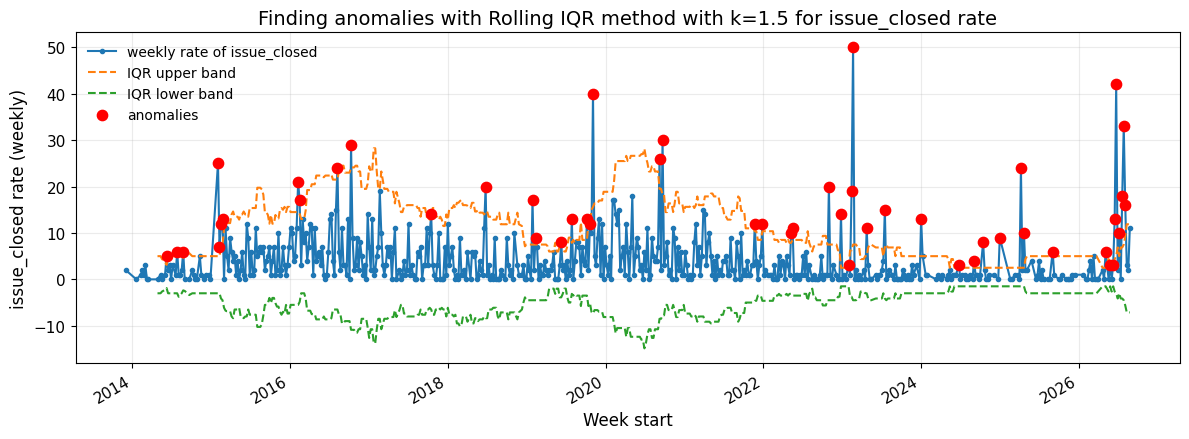

C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\functions\plotting_anomaly.py:228: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


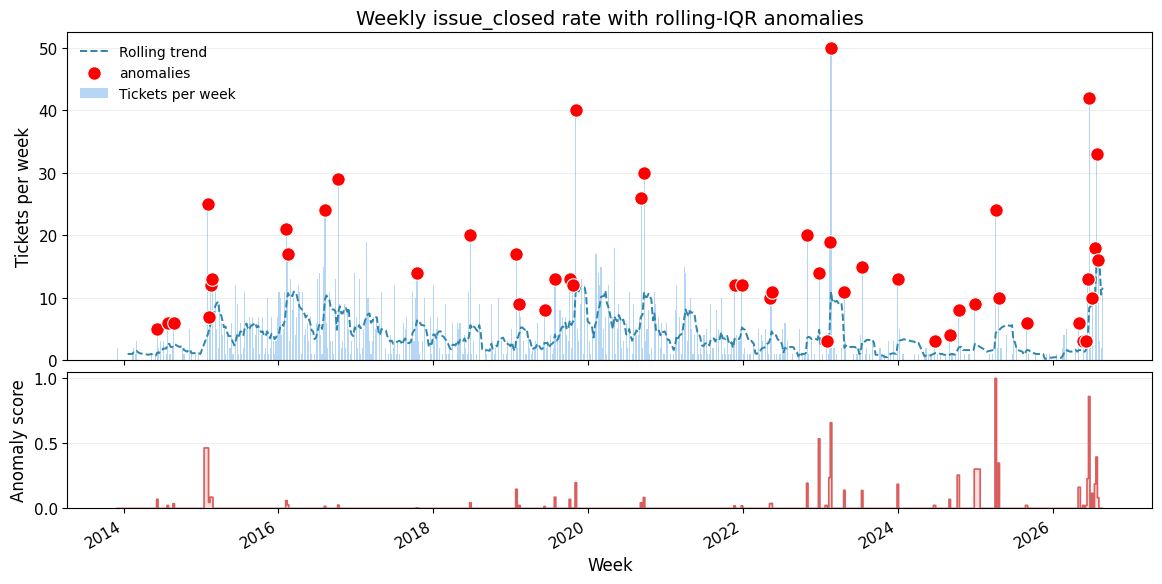

WindowsPath('C:/Users/mahsa.choopannezhadm/OneDrive - University of Liechtenstein/Desktop/PhD materials/codes/Lifecycles-Processes/results/figures/yargs')

In [4]:
from functions.plotting_anomaly import plot_anomaly_figures

plot_anomaly_figures(rolling_iqr_anomalies, cfg)


## 5. Commit context and type classification

Link commits to issues that closed in anomaly weeks via the same `event_id` join as 8b. Classify those messages for the weekly stacked plot, and save overlapping `anomaly_issue_commit_categories`.


commit_context summary: 50 rows x 17 columns
Saved commit_context to C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\results\tables\yargs\commit_context.csv

=== Anomaly issue commit categories (overlapping, event_id link) ===
Anomaly issues: 752
Issues with classified commits: 358
Issues with no classified commit (assigned to other): 394
Issues in more than one category: 69
  feature_work  28
  bug_fixes     74
  tech_debt     134
  docs          29
  other         586
Saved C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\results\tables\yargs\anomaly_issue_commit_categories.csv
commit_typeclass_per_week summary: 50 rows x 30 columns

Mean category ratios across all anomaly weeks:
  feature_work  0.036
  bug_fixes     0.124
  tech_debt     0.232
  docs          0.043
  other         0.485

Mean category ratios by anomaly_direction:
  [high] feature

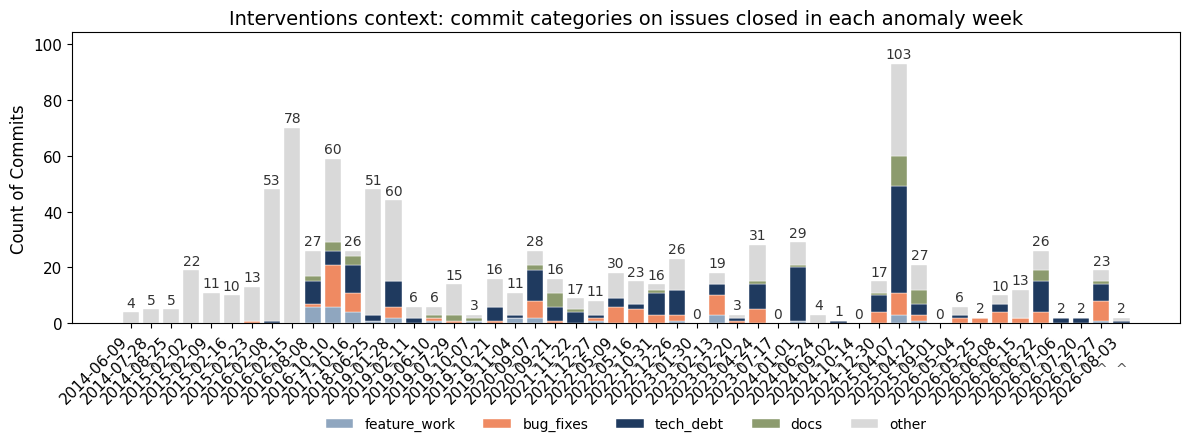

WindowsPath('C:/Users/mahsa.choopannezhadm/OneDrive - University of Liechtenstein/Desktop/PhD materials/codes/Lifecycles-Processes/results/figures/yargs')

In [5]:
from functions.commits import build_commit_context, build_commit_typeclass
from functions.plotting_anomaly import plot_commit_category_stack

commit_context, event_commit_message_join, anomaly_issue_commit_categories = build_commit_context(
    rolling_iqr_anomalies, eventsPerobj_df, objects_attributes, cfg, anomaly_object_ids
)
commit_typeclass_per_week = build_commit_typeclass(commit_context, cfg)
plot_commit_category_stack(commit_context, commit_typeclass_per_week, cfg)


## 6. Flatten OCEL2 issue log: viewpoint of issues


In [6]:
from functions.ocel_flatten import flatten_ocel2_issue_log

flat = flatten_ocel2_issue_log(cfg)


Flattened log: 33054 events, 2333 cases
  case:concept:name concept:name            time:timestamp
0             10003      created 2023-10-01 16:33:00+00:00
1             10003    commented 2023-10-02 10:29:25+00:00
2             10003    commented 2023-12-16 23:21:24+00:00
3             10003       closed 2023-12-16 23:21:24+00:00
4            100064    committed 2016-12-26 21:51:00+00:00
5            100064    committed 2016-12-26 21:51:00+00:00
6            100064    committed 2016-12-26 21:51:00+00:00
7            100064    committed 2016-12-26 21:51:00+00:00
8            100064    committed 2016-12-26 21:51:00+00:00
9            100064    committed 2016-12-26 21:51:00+00:00


## 7a. Category-log preprocess 

Clean the raw step-6 `flat` log for commit-category discovery: keep cases that contain `closed` or `head_ref_deleted` anywhere (full traces), then drop traces with any activity repeating more than `CATEGORY_MAX_REP` times. Independent of step 8 (`MAX_REP=5`).


In [7]:
from functions.preprocessing import preprocess_flat_log

CATEGORY_MAX_REP = 1000
flat_df_category_clean = preprocess_flat_log(flat, cfg, max_rep=CATEGORY_MAX_REP) 


=== Category-log preprocess (contain=closed/head_ref_deleted, max_rep=1000) ===
Raw: 2333 cases | 33054 events
After contain-end filter: 2333 cases | 33054 events
After max_rep=1000: 2333 cases | 33054 events


In [8]:
from functions.discovery import select_miners

# Available: alpha_classic, inductive_IM, heuristics_dep_0.5/0.6/0.7,
# inductive_IMf_noise_0.2/0.3/0.4, split_miner_eps_*_eta_*
# None runs all miners.
DISCOVERY_MINERS = [
    "inductive_IMf_noise_0.2",
    "split_miner_eps_0.2_eta_0.5",
    "heuristics_dep_0.5",
]


## 7b. Commit-category event logs (8a cleaned flat) and discovery in each action category

Classify every commit message and put each case from `flat_df_category_clean` into exactly one category log: if all of its commits share a category it stays there; if they span several categories (or it has no classified commit) it goes to `other`. Logs are disjoint. Then run discovery F1 on those five logs plus that cleaned whole log. Discovery methods come from `DISCOVERY_MINERS` in the cell after 8a (`None` runs all).


In [9]:
from functions.commits import build_whole_commit_category_logs
from functions.discovery import evaluate_clean_logs, select_miners

category_logs, issue_commit_categories, commit_classified_all = build_whole_commit_category_logs(
    flat_df_category_clean, eventsPerobj_df, objects_attributes, cfg
)

commit_category_log_groups_df = {**category_logs, "whole": flat_df_category_clean}

consolidated_results_table_commit_categories, commit_category_log_groups_eventlog, _ = evaluate_clean_logs(
    commit_category_log_groups_df,
    cfg,
    miners=select_miners(DISCOVERY_MINERS),
    out_filename="consolidated_results_table_commit_categories.csv"
)
canonical_whole_rows = consolidated_results_table_commit_categories[
    consolidated_results_table_commit_categories["log_name"] == "whole"
].copy()
consolidated_results_table_commit_categories.head()


=== Commit message classification (preprocessed whole log) ===
Preprocessed whole-log cases: 2333
Classified unique commits: 3131
  feature_work  140
  bug_fixes     366
  tech_debt     603
  docs          145
  other         1877
Saved C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\results\tables\yargs\commit_classified_all.csv

=== Issue commit categories (disjoint, preprocessed whole log) ===
Whole-log cases: 2333
Issues with classified commits: 1224
Issues with no classified commit (assigned to other): 1109
Issues with mixed commit categories (assigned to other): 249
Issues in issue_commit_categories: 2333
  feature_work  34
  bug_fixes     126
  tech_debt     235
  docs          46
  other         1892
Saved C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\results\tables\yargs\issue_commit_categories.csv

=== Preprocessed-log commit-category s

c:\Users\mahsa.choopannezhadm\anaconda3\envs\LCP\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
replaying log with TBR, completed traces :: 100%|██████████| 1795/1795 [00:25<00:00, 71.21it/s] 

Expected records: 18 | Observed: 18

7) Consolidated results table in clean logs
        log_name             discovery_method  n_cases  avg_cycle_time_days  \
0      bug_fixes           heuristics_dep_0.5      126           469.321353   
1           docs           heuristics_dep_0.5       46            62.958603   
2   feature_work           heuristics_dep_0.5       34           563.977243   
3          other           heuristics_dep_0.5     1892           559.402942   
4      tech_debt           heuristics_dep_0.5      235            85.624608   
5          whole           heuristics_dep_0.5     2333           497.092997   
6      bug_fixes      inductive_IMf_noise_0.2      126           469.321353   
7           docs      inductive_IMf_noise_0.2       46            62.958603   
8   feature_work      inductive_IMf_noise_0.2       34           563.977243   
9          other      inductive_IMf_noise_0.2     1892           559.402942   
10     tech_debt      inductive_IMf_noise_0.2     

,log_name,discovery_method,n_cases,avg_cycle_time_days,avg_trace_length,generalization,fitness,precision,f_score,size,cfc,simplicity,status,error
0,bug_fixes,heuristics_dep_0.5,126,469.321353,12.158730,0.449404,0.877340,0.567199,0.688976,452.0,27.0,0.461741,ok,None
1,docs,heuristics_dep_0.5,46,62.958603,7.782609,0.485540,0.911964,0.594709,0.719935,186.0,6.0,0.546099,ok,None
2,feature_work,heuristics_dep_0.5,34,563.977243,17.235294,0.447413,0.892100,0.345426,0.498017,253.0,12.0,0.497537,ok,None
3,other,heuristics_dep_0.5,1892,559.402942,14.955603,0.563474,0.925802,0.346672,0.504449,968.0,52.0,0.423212,ok,None
4,tech_debt,heuristics_dep_0.5,235,85.624608,9.710638,0.596791,0.834200,0.578835,0.683443,381.0,19.0,0.465409,ok,None


## 7c. Anomaly vs normal logs from cleaned flat, then discovery F1

Split `flat_df_category_clean` by anomaly object IDs from step 3: keep matching cases as the anomaly log and the rest as the normal log. Then run discovery F1 on anomaly and normal using `DISCOVERY_MINERS`. Whole-log F1 is copied from 7b (`canonical_whole_rows`), not rediscovered.


In [10]:
from functions.ocel_flatten import split_flat_by_anomaly_object_ids
from functions.discovery import evaluate_clean_logs, select_miners
import pandas as pd

anomaly_log_df, normal_log_df = split_flat_by_anomaly_object_ids(
    flat_df_category_clean, anomaly_object_ids
)

anomaly_normal_log_groups_df = {
    "anomaly": anomaly_log_df,
    "normal": normal_log_df,
}

consolidated_results_table_anomaly_normal, _, _ = evaluate_clean_logs(
    anomaly_normal_log_groups_df,
    cfg,
    miners=select_miners(DISCOVERY_MINERS),
    out_filename="consolidated_results_table_anomaly_normal.csv",
)
consolidated_results_table_anomaly_normal = pd.concat(
    [consolidated_results_table_anomaly_normal, canonical_whole_rows],
    ignore_index=True,
).sort_values(["discovery_method", "log_name"]).reset_index(drop=True)
consolidated_results_table_anomaly_normal.to_csv(
    cfg.tables_dir / "consolidated_results_table_anomaly_normal.csv",
    index=False,
)
anomaly_normal_log_groups_df["whole"] = flat_df_category_clean
consolidated_results_table_anomaly_normal


Anomaly log: 752 cases | 10682 events
Normal log: 1581 cases | 22372 events


replaying log with TBR, completed traces :: 100%|██████████| 1261/1261 [00:12<00:00, 98.38it/s] 

Expected records: 6 | Observed: 6

7) Consolidated results table in clean logs
  log_name             discovery_method  n_cases  avg_cycle_time_days  \
0  anomaly           heuristics_dep_0.5      752           799.428569   
1   normal           heuristics_dep_0.5     1581           353.287589   
2  anomaly      inductive_IMf_noise_0.2      752           799.428569   
3   normal      inductive_IMf_noise_0.2     1581           353.287589   
4  anomaly  split_miner_eps_0.2_eta_0.5      752           799.428569   
5   normal  split_miner_eps_0.2_eta_0.5     1581           353.287589   

   avg_trace_length  generalization   fitness  precision   f_score   size  \
0         14.204787        0.593077  0.911585   0.319663  0.473341  716.0   
1         14.150538        0.587074  0.881261   0.299503  0.447067  933.0   
2         14.204787        0.840083  0.971990   0.449993  0.615181  321.0   
3         14.150538        0.870323  0.949131   0.307949  0.465020  310.0   
4         14.204787     

,log_name,discovery_method,n_cases,avg_cycle_time_days,avg_trace_length,generalization,fitness,precision,f_score,size,cfc,simplicity,status,error
0,anomaly,heuristics_dep_0.5,752,799.428569,14.204787,0.593077,0.911585,0.319663,0.473341,716.0,42.0,0.423138,ok,None
1,normal,heuristics_dep_0.5,1581,353.287589,14.150538,0.587074,0.881261,0.299503,0.447067,933.0,62.0,0.415162,ok,None
2,whole,heuristics_dep_0.5,2333,497.092997,14.168024,0.546184,0.884980,0.295257,0.442786,1107.0,71.0,0.414387,ok,None
3,anomaly,inductive_IMf_noise_0.2,752,799.428569,14.204787,0.840083,0.971990,0.449993,0.615181,321.0,9.0,0.617778,ok,None
4,normal,inductive_IMf_noise_0.2,1581,353.287589,14.150538,0.870323,0.949131,0.307949,0.465020,310.0,7.0,0.614679,ok,None
5,whole,inductive_IMf_noise_0.2,2333,497.092997,14.168024,0.875438,0.979619,0.306355,0.466746,474.0,17.0,0.624242,ok,None
6,anomaly,split_miner_eps_0.2_eta_0.5,752,799.428569,14.204787,0.766059,0.757787,0.426582,0.545874,605.0,148.0,0.315113,ok,None
7,normal,split_miner_eps_0.2_eta_0.5,1581,353.287589,14.150538,0.797052,0.789412,0.433227,0.559437,579.0,104.0,0.358423,ok,None
8,whole,split_miner_eps_0.2_eta_0.5,2333,497.092997,14.168024,0.780178,0.649083,0.626734,0.637713,806.0,216.0,0.305589,ok,None


## 7d. Anomaly x commit-category logs, then discovery F1

Cross `anomaly_log_df` / `normal_log_df` from 8c with disjoint `category_logs` from 8b: each case belongs to exactly one category, then those logs are split into anomaly vs normal. Then run discovery F1 on the ten combined groups using `DISCOVERY_MINERS`. Whole-log F1 is copied from 7b (`canonical_whole_rows`), not rediscovered.


In [11]:
from functions.discovery import evaluate_clean_logs, select_miners
import pandas as pd

anomaly_ids = set(anomaly_log_df["case:concept:name"].astype(str))
normal_ids = set(normal_log_df["case:concept:name"].astype(str))

anomaly_category_log_groups_df = {
    **{f"anomaly_{name}": df[df["case:concept:name"].astype(str).isin(anomaly_ids)].copy()
       for name, df in category_logs.items()},
    **{f"normal_{name}": df[df["case:concept:name"].astype(str).isin(normal_ids)].copy()
       for name, df in category_logs.items()},
}

consolidated_results_table_anomaly_categories, _, _ = evaluate_clean_logs(
    anomaly_category_log_groups_df,
    cfg,
    miners=select_miners(DISCOVERY_MINERS),
    out_filename="consolidated_results_table_anomaly_categories.csv",
)
consolidated_results_table_anomaly_categories = pd.concat(
    [consolidated_results_table_anomaly_categories, canonical_whole_rows],
    ignore_index=True,
).sort_values(["discovery_method", "log_name"]).reset_index(drop=True)
consolidated_results_table_anomaly_categories.to_csv(
    cfg.tables_dir / "consolidated_results_table_anomaly_categories.csv",
    index=False,
)
consolidated_results_table_anomaly_categories


replaying log with TBR, completed traces :: 100%|██████████| 1075/1075 [00:13<00:00, 82.60it/s]

Expected records: 30 | Observed: 30

7) Consolidated results table in clean logs
                log_name             discovery_method  n_cases  \
0      anomaly_bug_fixes           heuristics_dep_0.5       36   
1           anomaly_docs           heuristics_dep_0.5       12   
2   anomaly_feature_work           heuristics_dep_0.5        9   
3          anomaly_other           heuristics_dep_0.5      599   
4      anomaly_tech_debt           heuristics_dep_0.5       96   
5       normal_bug_fixes           heuristics_dep_0.5       90   
6            normal_docs           heuristics_dep_0.5       34   
7    normal_feature_work           heuristics_dep_0.5       25   
8           normal_other           heuristics_dep_0.5     1293   
9       normal_tech_debt           heuristics_dep_0.5      139   
10     anomaly_bug_fixes      inductive_IMf_noise_0.2       36   
11          anomaly_docs      inductive_IMf_noise_0.2       12   
12  anomaly_feature_work      inductive_IMf_noise_0.2        

,log_name,discovery_method,n_cases,avg_cycle_time_days,avg_trace_length,generalization,fitness,precision,f_score,size,cfc,simplicity,status,error
0,anomaly_bug_fixes,heuristics_dep_0.5,36,567.703286,13.027778,0.453754,0.905231,0.695560,0.786664,297.0,14.0,0.502110,ok,None
1,anomaly_docs,heuristics_dep_0.5,12,77.587341,6.333333,0.343454,0.939575,0.555556,0.698248,109.0,1.0,0.610390,ok,None
2,anomaly_feature_work,heuristics_dep_0.5,9,688.956713,18.666667,0.393475,0.885977,0.528169,0.661807,153.0,7.0,0.561404,ok,None
3,anomaly_other,heuristics_dep_0.5,599,938.994242,15.116861,0.549858,0.910096,0.345296,0.500644,682.0,42.0,0.425710,ok,None
4,anomaly_tech_debt,heuristics_dep_0.5,96,116.080787,9.520833,0.518718,0.848703,0.454738,0.592183,379.0,20.0,0.463722,ok,None
5,normal_bug_fixes,heuristics_dep_0.5,90,429.968581,11.811111,0.437897,0.858207,0.739097,0.794211,422.0,28.0,0.452514,ok,None
6,normal_docs,heuristics_dep_0.5,34,57.795519,8.294118,0.476144,0.903719,0.625862,0.739553,177.0,5.0,0.560606,ok,None
7,normal_feature_work,heuristics_dep_0.5,25,518.984634,16.720000,0.436426,0.902140,0.397476,0.551823,223.0,9.0,0.526012,ok,None
8,normal_other,heuristics_dep_0.5,1293,383.552061,14.880897,0.580424,0.885230,0.304541,0.453178,841.0,50.0,0.421265,ok,None
9,normal_tech_debt,heuristics_dep_0.5,139,64.590126,9.841727,0.550528,0.858654,0.451058,0.591432,398.0,24.0,0.461078,ok,None


In [12]:
import pandas as pd

xlsx_path = cfg.tables_dir / "consolidated_results_tables.xlsx"
with pd.ExcelWriter(xlsx_path, engine="openpyxl") as writer:
    consolidated_results_table_commit_categories.to_excel(
        writer, sheet_name="commit_categories", index=False
    )
    consolidated_results_table_anomaly_normal.to_excel(
        writer, sheet_name="anomaly_normal", index=False
    )
    consolidated_results_table_anomaly_categories.to_excel(
        writer, sheet_name="anomaly_categories", index=False
    )
print(f"Saved {xlsx_path}")


Saved C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\results\tables\yargs\consolidated_results_tables.xlsx


## 8. Petri nets by commit category: events related to each commit category


the question:

what process is discovered for each disjoint commit category in the preprocessed whole log?

the input:

category_logs from step 8b (disjoint category subsets of flat_df_category_clean)

the output:

petri net per category log (inductive_IMf_noise_0.2)


In [13]:
#graphviz path 
import os
from pathlib import Path
import shutil

GRAPHVIZ_BIN = Path(r"C:\Program Files\Graphviz\bin")  # change if yours is elsewhere

if not (GRAPHVIZ_BIN / "dot.exe").exists():
    raise FileNotFoundError(
        f"dot.exe not found in {GRAPHVIZ_BIN}. "
        "Install Graphviz and set GRAPHVIZ_BIN to its bin folder."
    )

os.environ["PATH"] = str(GRAPHVIZ_BIN) + os.pathsep + os.environ.get("PATH", "")
print("dot found at:", shutil.which("dot"))

dot found at: C:\Program Files\Graphviz\bin\dot.EXE


feature_work


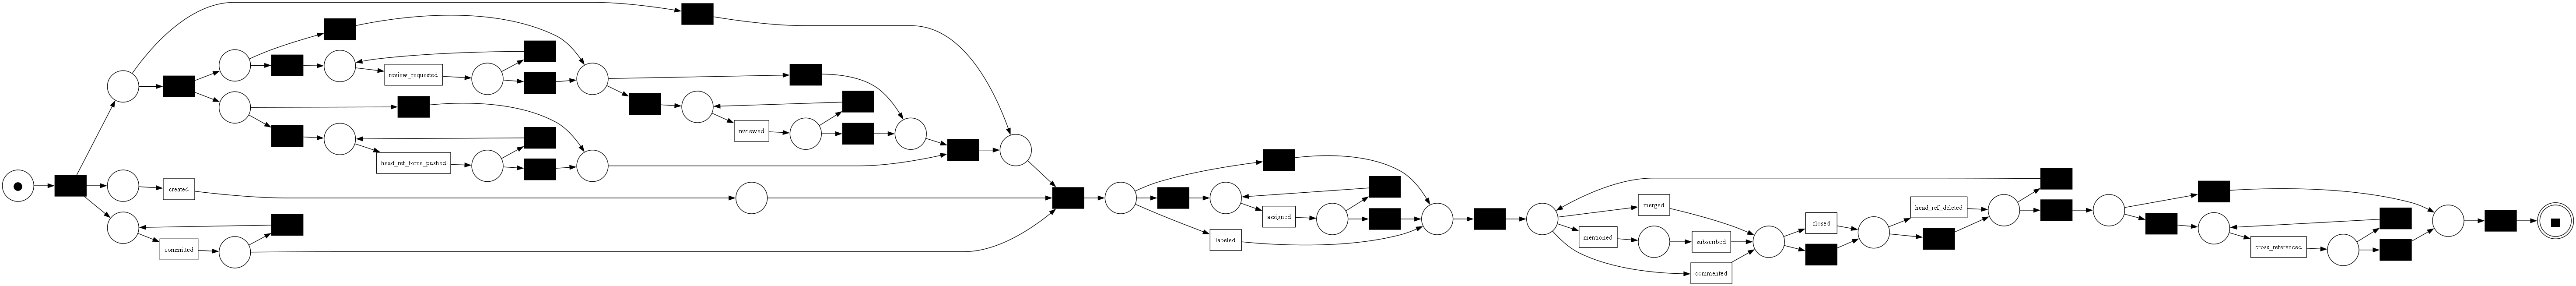

bug_fixes


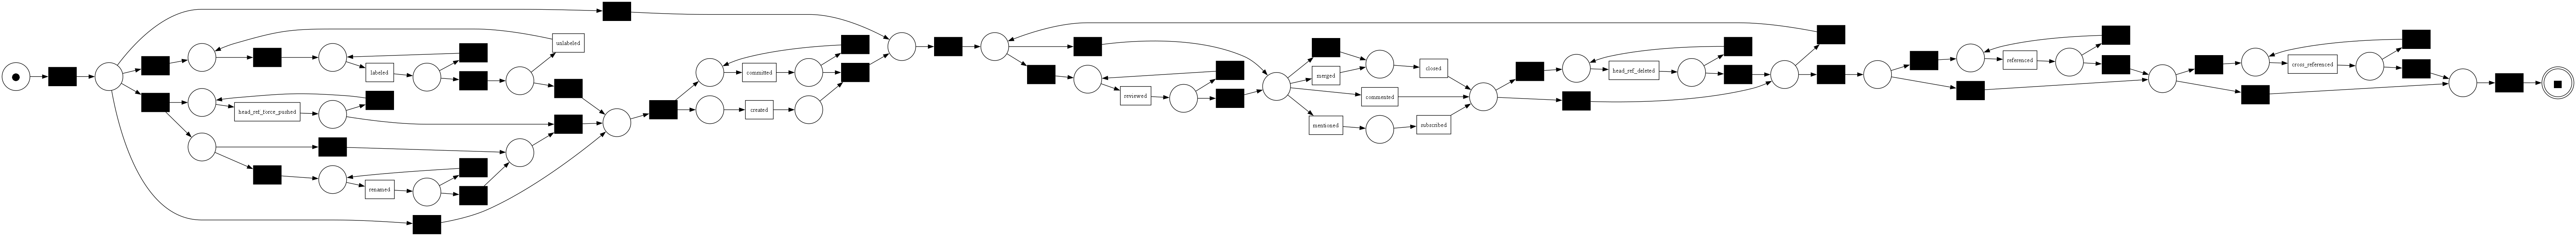

tech_debt


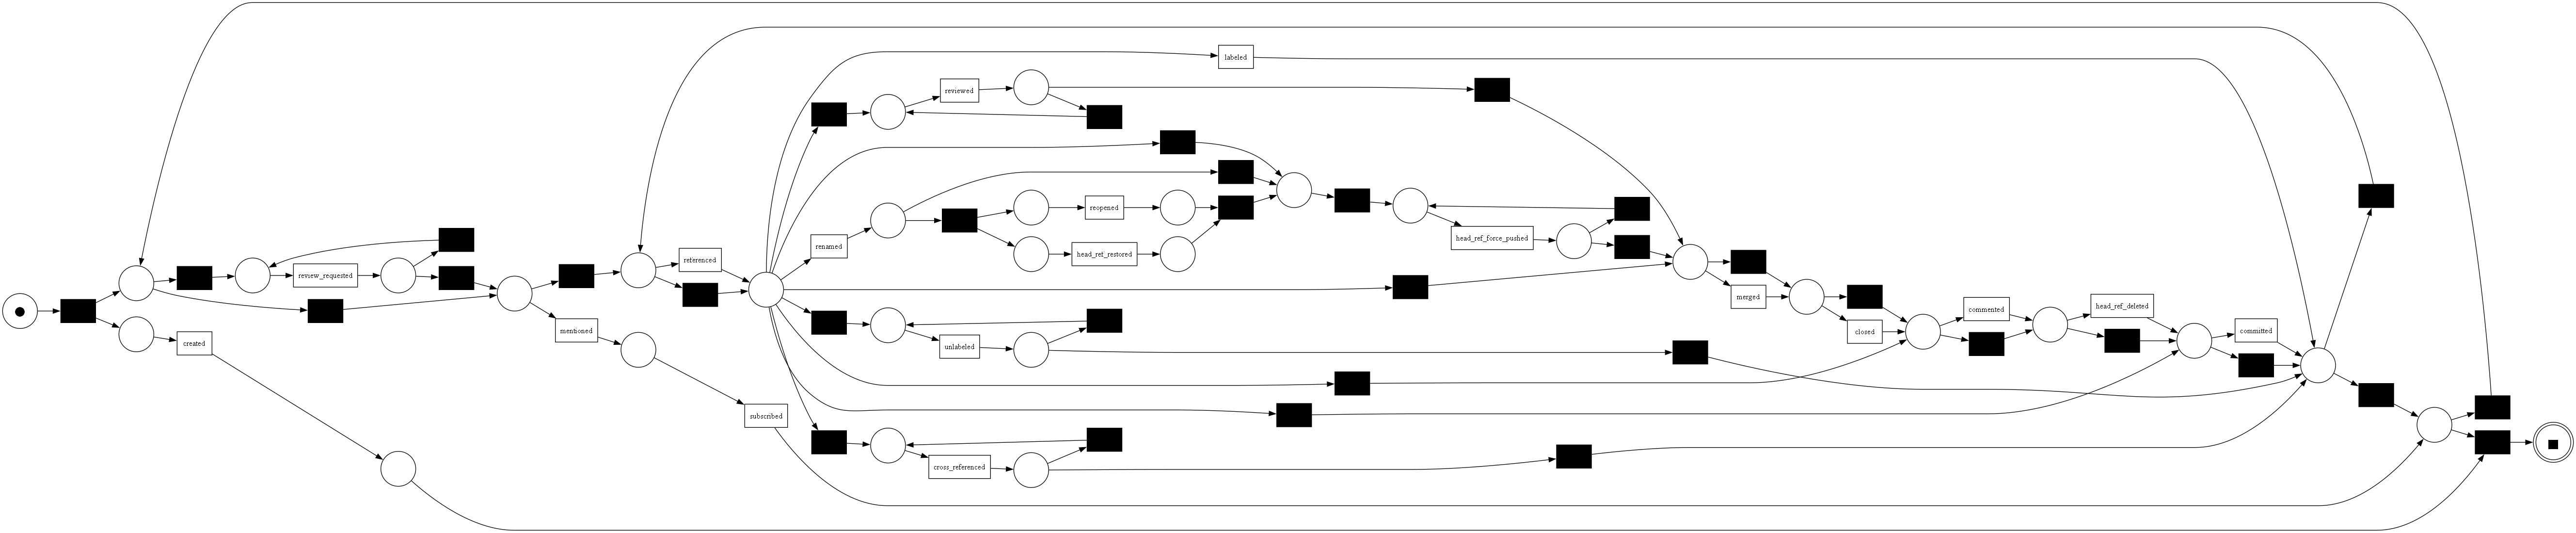

docs


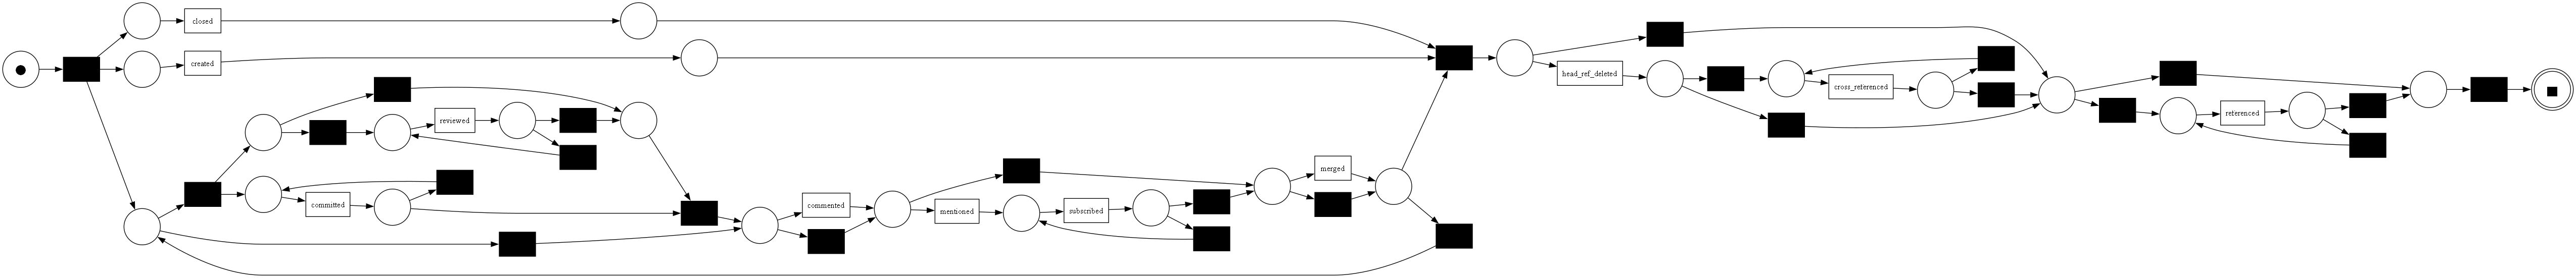

other


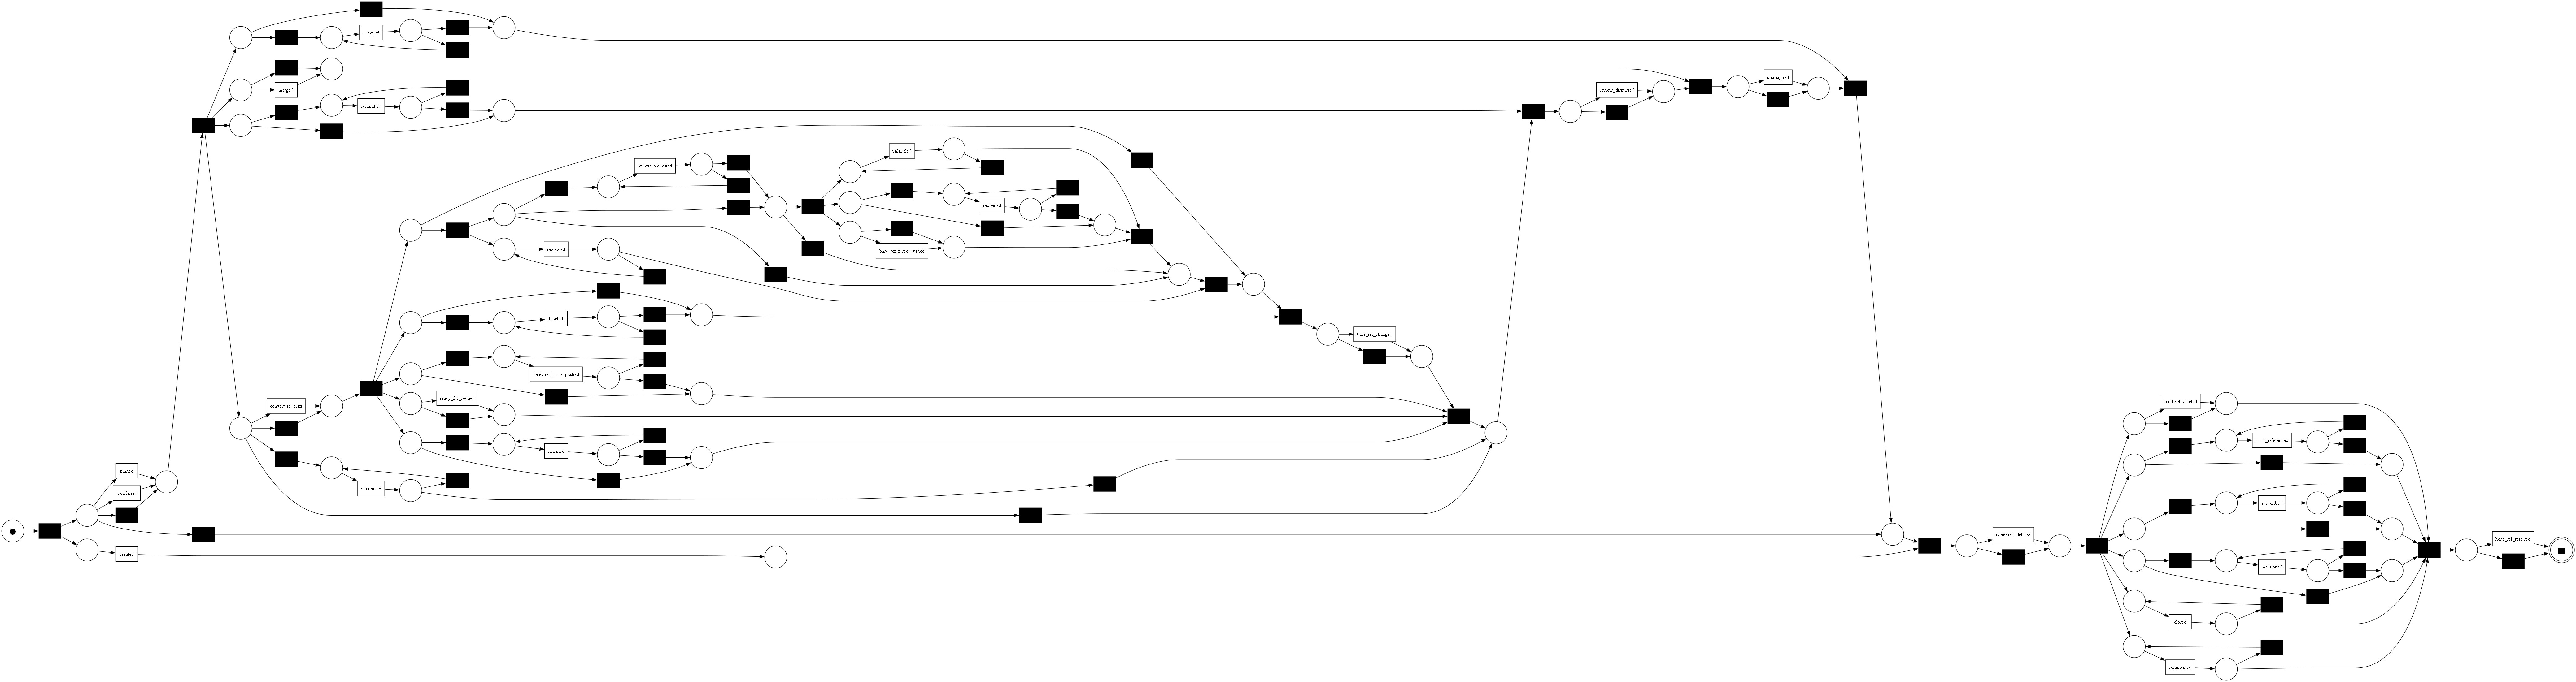

In [14]:
import pm4py
from functions.discovery import df_to_event_log, select_miners

miners = select_miners(["inductive_IMf_noise_0.2"])

for name, df in category_logs.items():
    print(name)
    elog = df_to_event_log(df)
    net, im, fm = miners["inductive_IMf_noise_0.2"](elog)
    pm4py.view_petri_net(net, im, fm)


## 9. Petri nets by anomaly, normal, and whole

the question:

    what process is discovered for anomaly vs normal vs the whole cleaned log?

the input:

    anomaly_normal_log_groups_df from step 8c

the output:

    petri net per log (inductive_IMf_noise_0.2)

anomaly


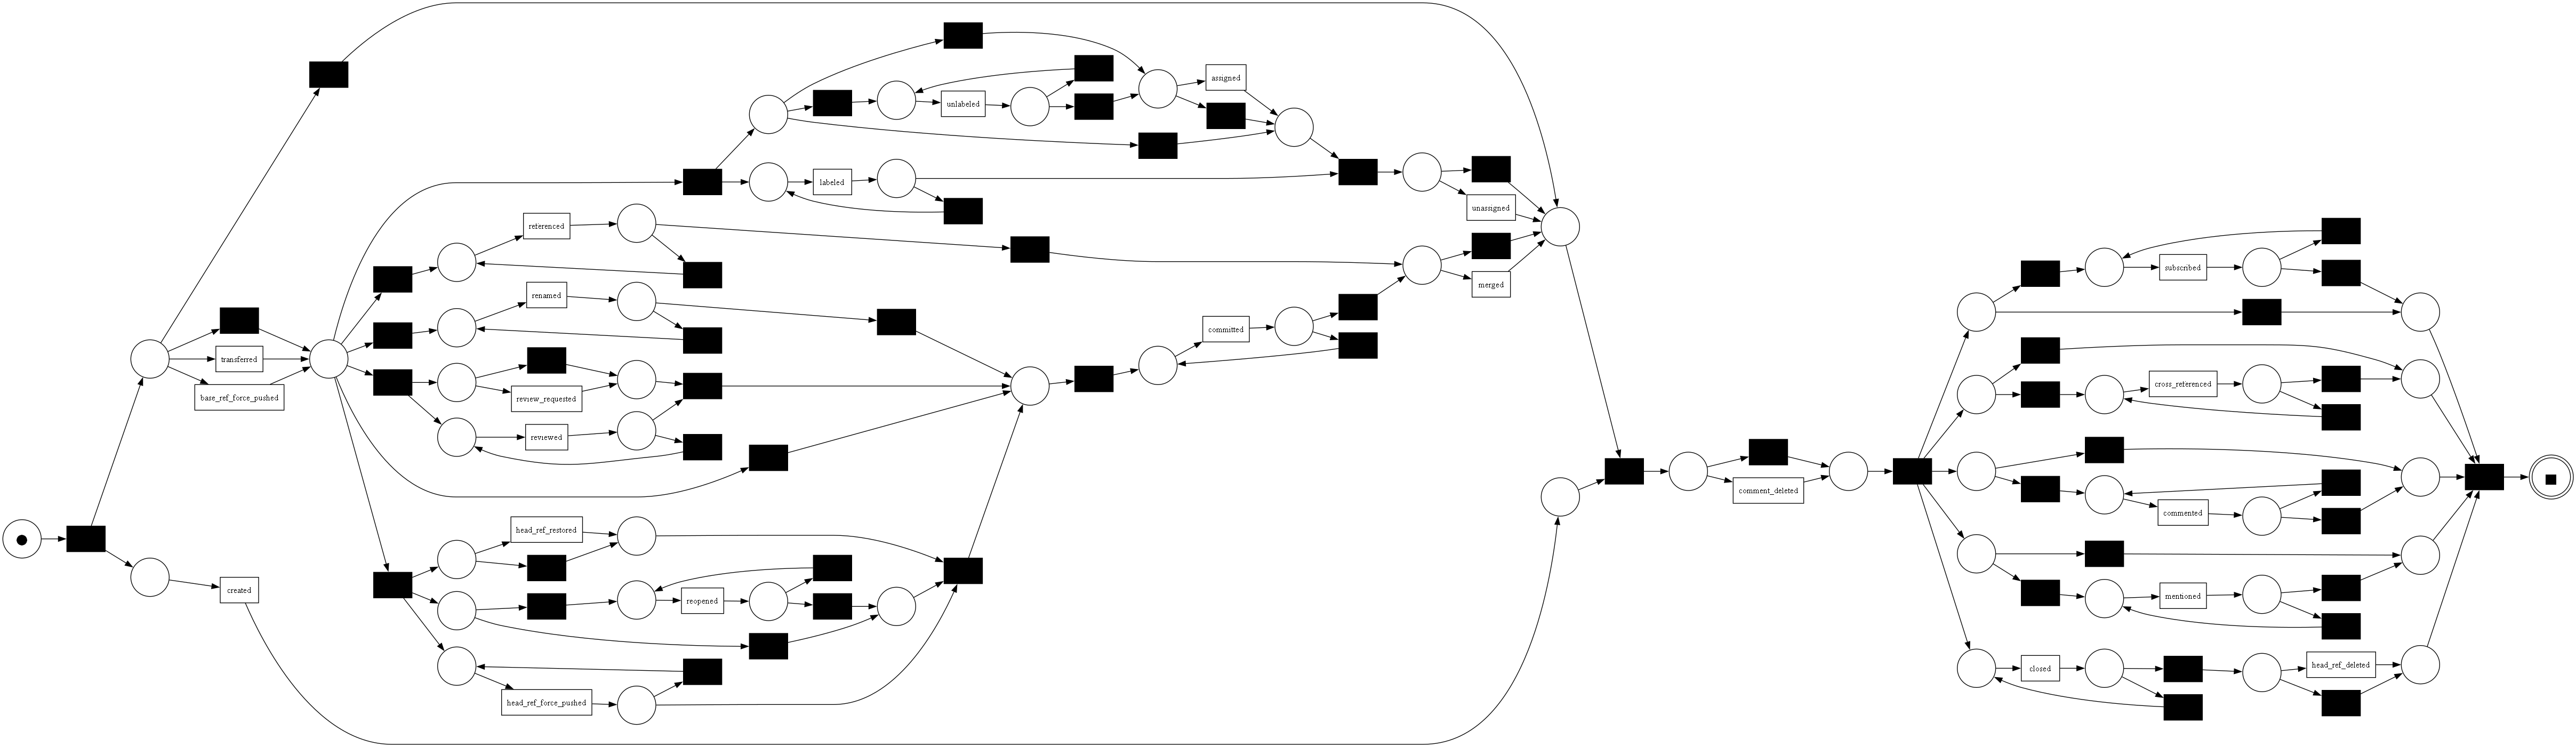

normal


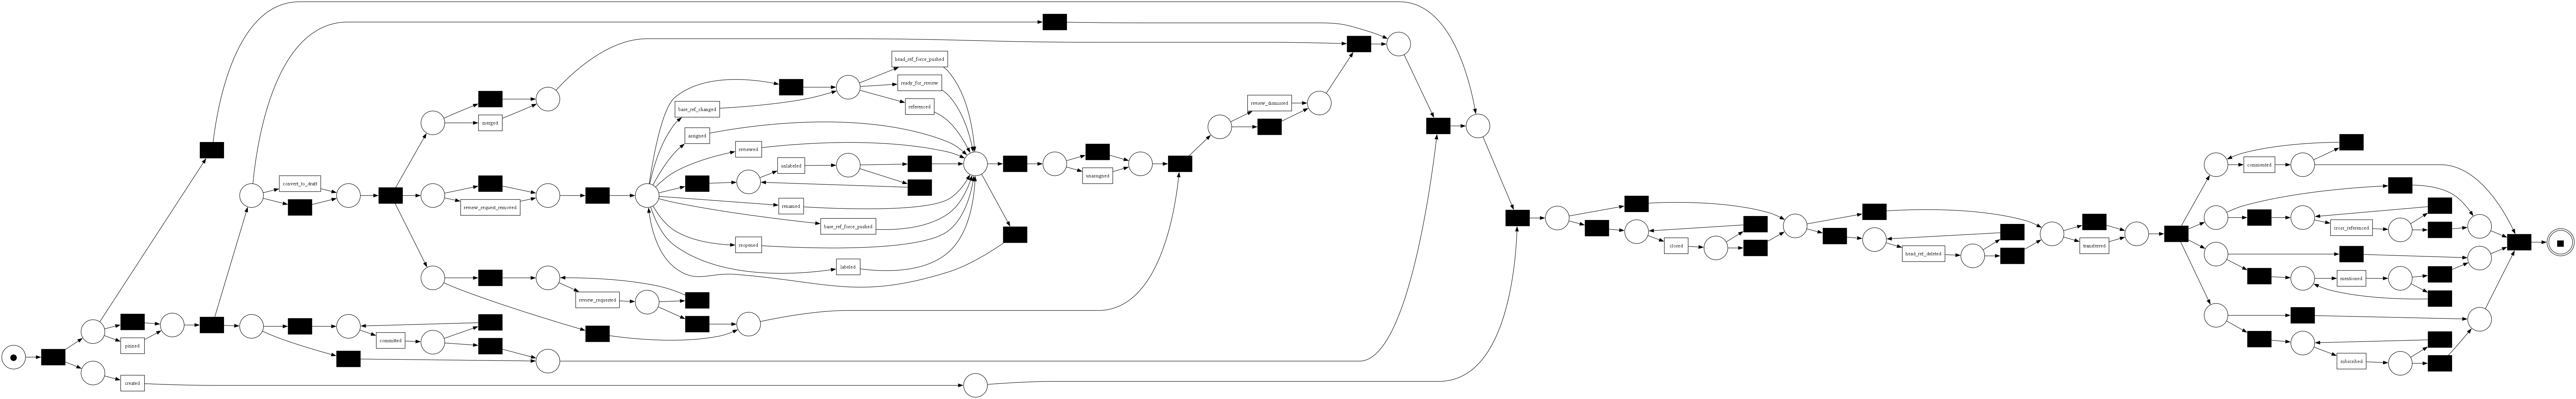

whole


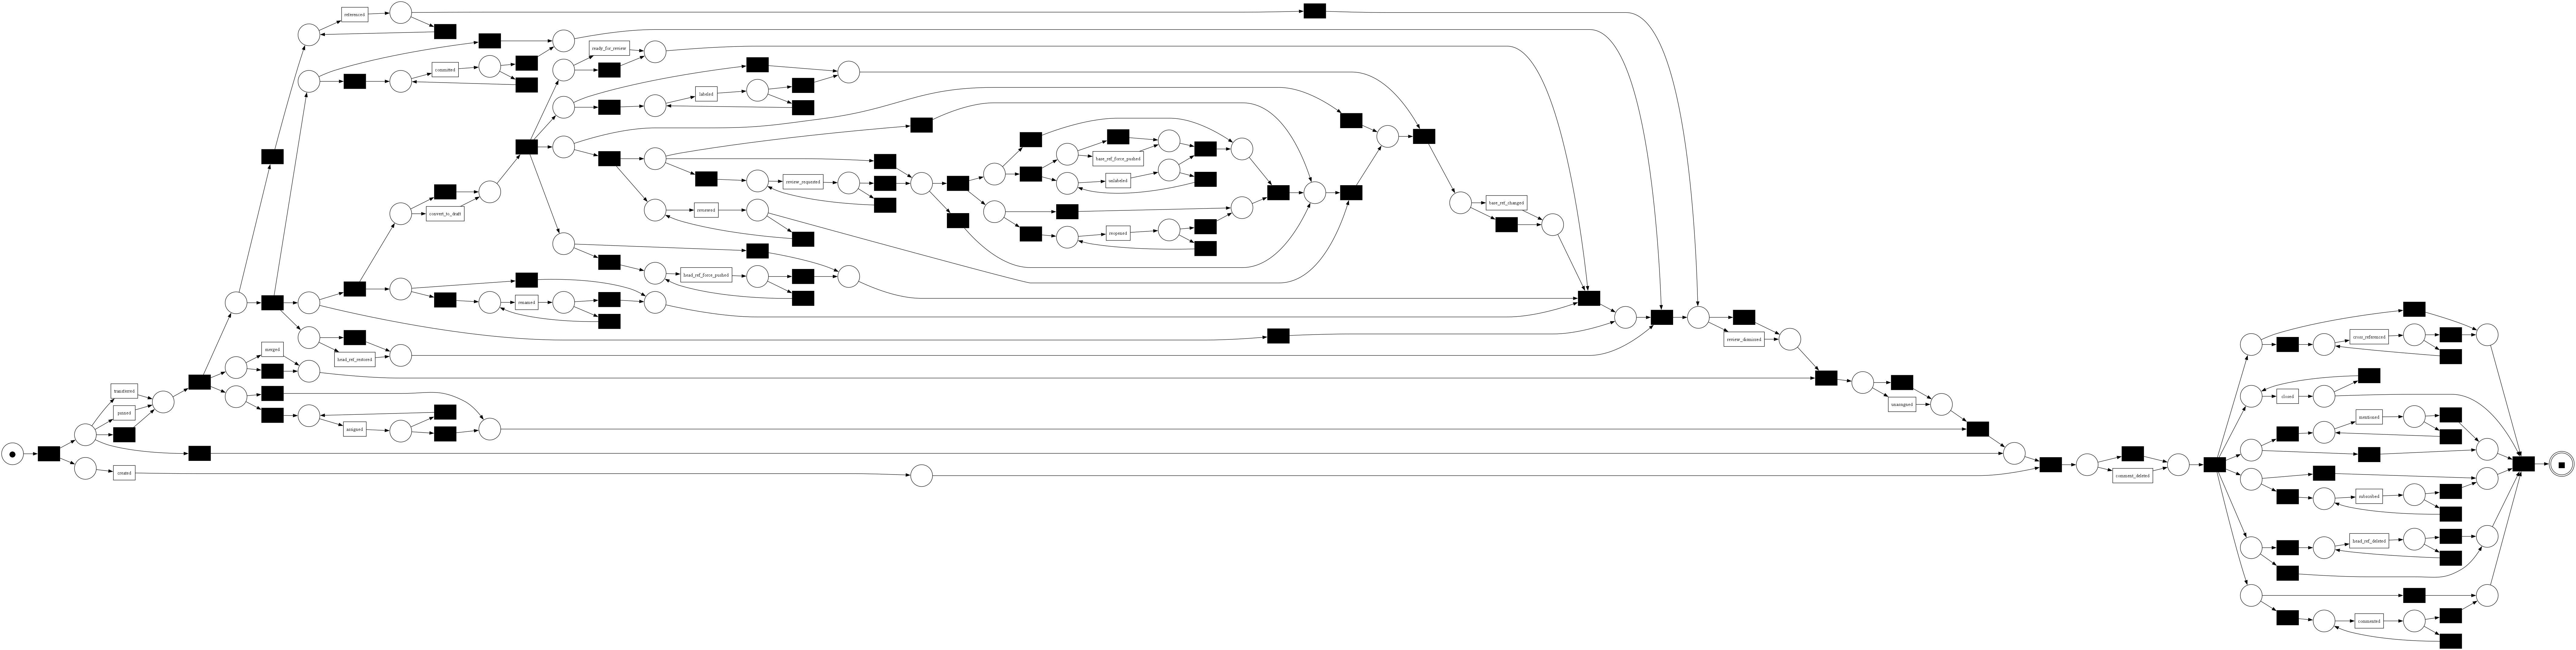

In [15]:
import pm4py
from functions.discovery import df_to_event_log, select_miners

miners = select_miners(["inductive_IMf_noise_0.2"])

for name, df in anomaly_normal_log_groups_df.items():
    print(name)
    elog = df_to_event_log(df)
    net, im, fm = miners["inductive_IMf_noise_0.2"](elog)
    pm4py.view_petri_net(net, im, fm)
